In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvZW1tYW51ZWwvRG9jdW1lbnRvcy9Qcm95ZWN0cy9NTF9wcm95ZWN0cy9Qcm95ZWN0by1kZS1maW4tZGUtbW9kdWxvLS0tQWxmYXJvLUJhZGlsbG8tQ3J1ei1QZXJlei1SdXBpdC0tLWNvcGlhU2VsaW0vbWlzX3JlcG9ydGVz'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/home/emmanuel/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/importlib/_bootstrap.py": 1788106362.2752662, "/home/emmanuel/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/importlib/_bootstrap_external.py": 1788106362.279266, "/home/emmanuel/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/zipimport.py": 1788106362.3632689, "/home/emmanuel/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/codecs.py": 1788106362.2112641, "/home/emmanuel/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/encodings/aliases.py": 1788106362.2272646, "/home/emmanuel/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/encodings/__init__.py": 1788106362.2272646, "/home/emmanuel/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/encodings/utf_8.py": 1788106362.2352648, "/home/emmanuel/.local/share/uv/python/cpython-3.14.5-linux-x86_64-gnu/lib/python3.14/abc.py": 1788106

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo visual para reportes
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 11})

# 1. Carga de la base analítica
df_analitico = pd.read_parquet("../data/processed/sequia_analitico_2016.parquet")

# Asegurar formato correcto de fechas
df_analitico['fecha'] = pd.to_datetime(df_analitico['fecha'])
df_analitico['anio'] = df_analitico['fecha'].dt.year

# Normalización de categorías de sequía (D0 a D4 y Sin Sequía)
cat_order = ['Sin Sequía', 'D0', 'D1', 'D2', 'D3', 'D4']

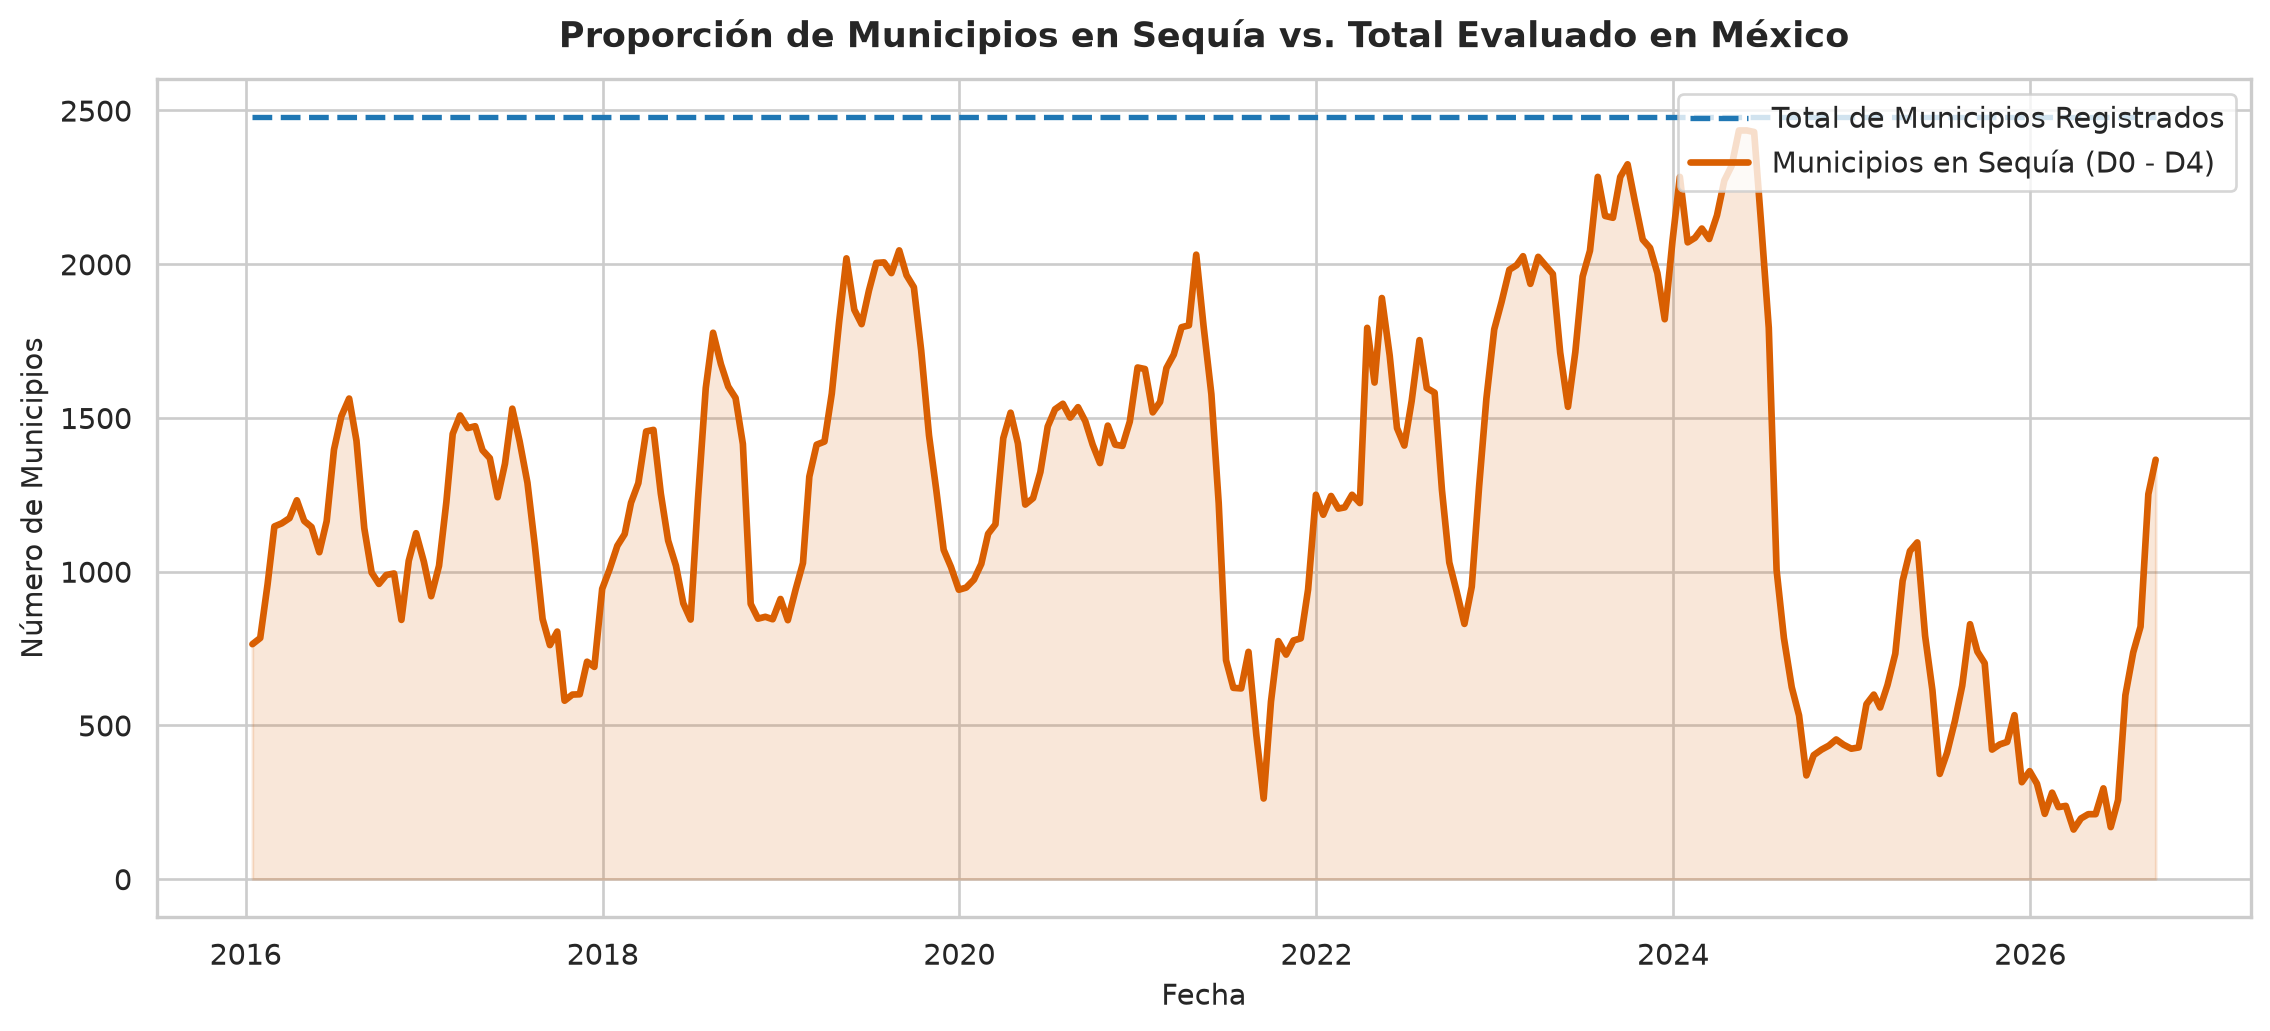

In [3]:
# GRAFICA 1: Municipios que presentan sequía vs Total de municipios en el tiempo
df_g1 = df_analitico.groupby('fecha').agg(
    total_municipios=('CVE_CONCATENADA', 'nunique'),
    municipios_en_sequia=('en_sequia', lambda x: (x > 0).sum())
).reset_index()

plt.figure(figsize=(12, 5.5))
plt.plot(df_g1['fecha'], df_g1['total_municipios'], label='Total de Municipios Registrados', color='#1f77b4', linestyle='--', linewidth=2)
plt.plot(df_g1['fecha'], df_g1['municipios_en_sequia'], label='Municipios en Sequía (D0 - D4)', color='#d95f02', linewidth=2.5)
plt.fill_between(df_g1['fecha'], df_g1['municipios_en_sequia'], color='#d95f02', alpha=0.15)
plt.title('Proporción de Municipios en Sequía vs. Total Evaluado en México', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Fecha', fontsize=11)
plt.ylabel('Número de Municipios', fontsize=11)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.savefig('grafica1_municipios_vs_total.png', dpi=300)
plt.show()

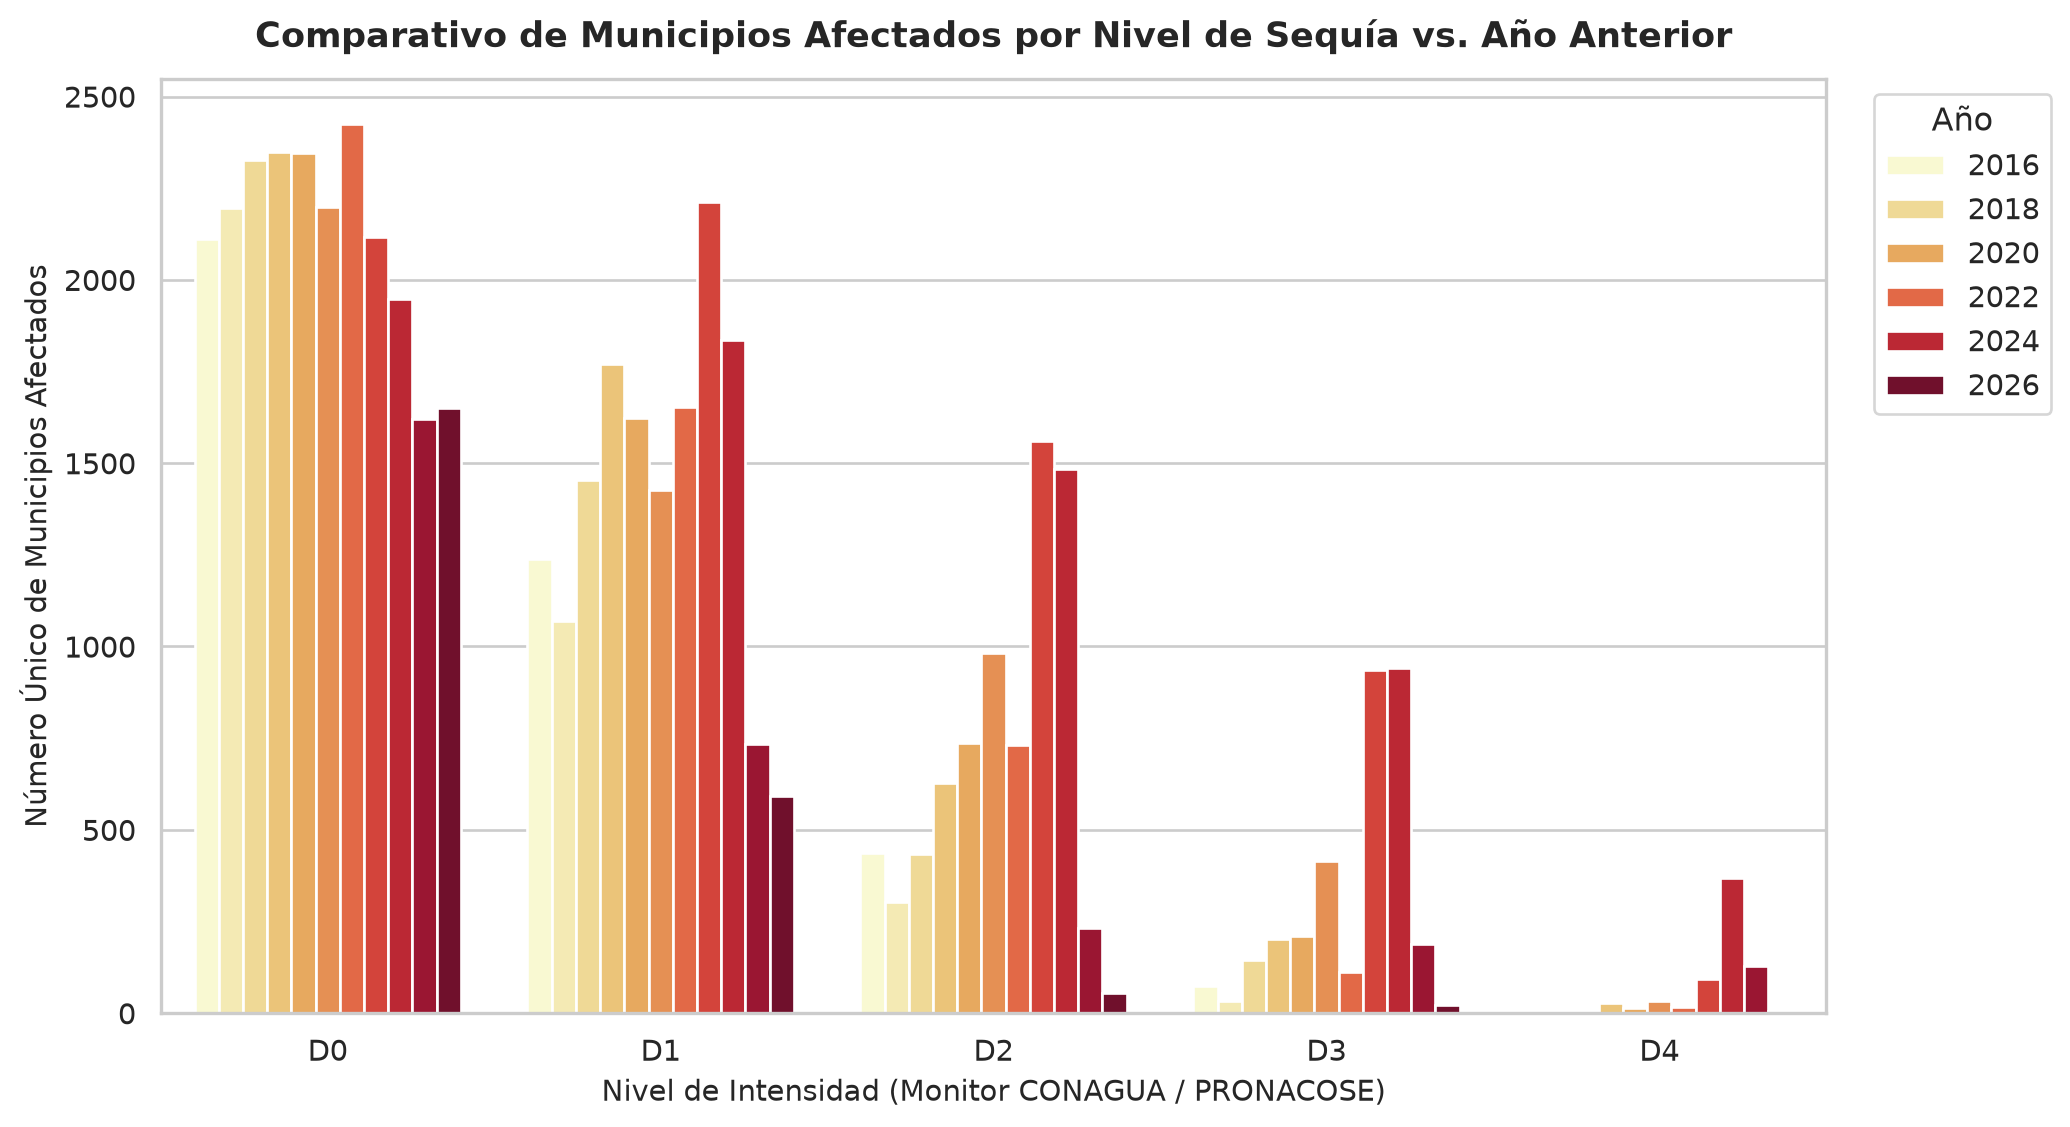

In [4]:
# GRAFICA 2: Comparativo de Municipios por Nivel de Sequía
# 1. Asegurar formato de fecha y año
df_analitico['fecha'] = pd.to_datetime(df_analitico['fecha'])
df_analitico['anio'] = df_analitico['fecha'].dt.year

# 2. Mapeo de códigos numéricos (1-5) a categorías de sequía (D0-D4)
mapa_intensidad = {
    1: 'D0',
    2: 'D1',
    3: 'D2',
    4: 'D3',
    5: 'D4'
}

# 3. Filtrar niveles con afectación (1 a 5)
df_filtrado = df_analitico[df_analitico['intensidad'].isin([1, 2, 3, 4, 5])].copy()
df_filtrado['intensidad_nom'] = df_filtrado['intensidad'].map(mapa_intensidad)

# 4. Agrupar por año y nivel mapeado
df_g2 = df_filtrado.groupby(['anio', 'intensidad_nom'])['CVE_CONCATENADA'].nunique().reset_index()

# 5. Dibujar la gráfica
plt.figure(figsize=(11, 6))

sns.barplot(
    data=df_g2,
    x='intensidad_nom',
    y='CVE_CONCATENADA',
    hue='anio',
    palette='YlOrRd',
    order=['D0', 'D1', 'D2', 'D3', 'D4']
)

plt.title('Comparativo de Municipios Afectados por Nivel de Sequía vs. Año Anterior', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Nivel de Intensidad (Monitor CONAGUA / PRONACOSE)', fontsize=11)
plt.ylabel('Número Único de Municipios Afectados', fontsize=11)
plt.legend(title='Año', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()

plt.savefig('grafica2_niveles_vs_anio.png', dpi=300)
plt.show()

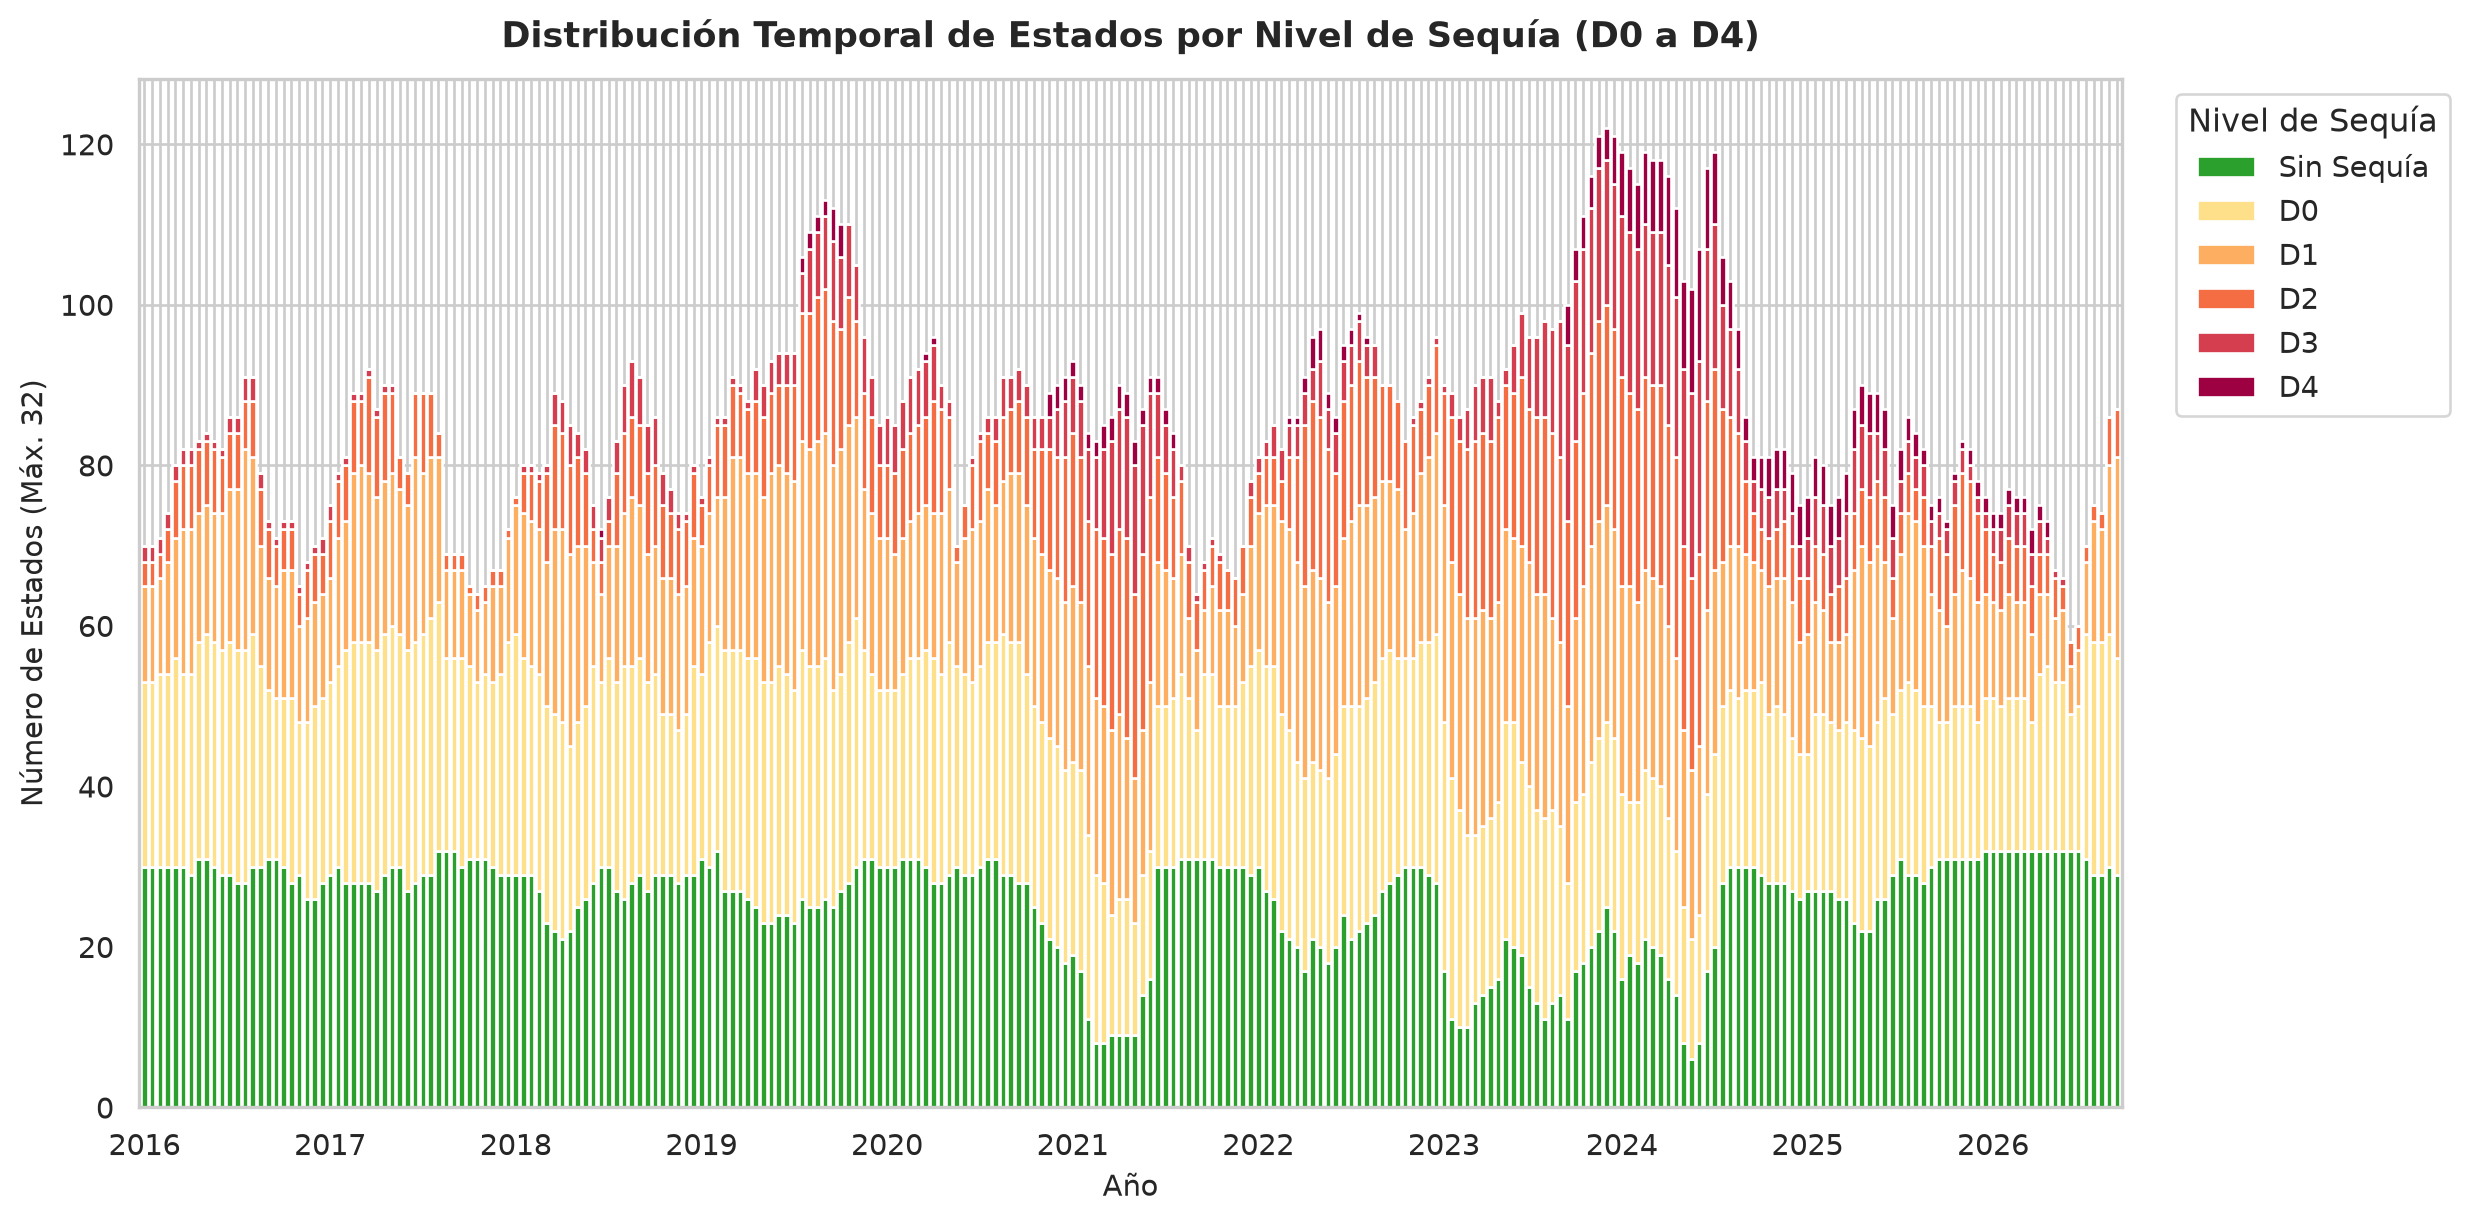

In [5]:
# GRAFICA 3: Barras apiladas con etiquetas por año en el eje X a nivel estado/entidad
# 1. Preparar la clasificación categórica
df_analitico['clasificacion_para_grafica'] = df_analitico['clasificacion_sequia'].fillna('Sin Sequía')
df_analitico['clasificacion_para_grafica'] = pd.Categorical(
    df_analitico['clasificacion_para_grafica'],
    categories=cat_order,
    ordered=True
)

# 2. Agrupar por fecha y nivel de sequía contando ESTADOS ÚNICOS (ENTIDAD)
df_g3_estado = df_analitico.groupby(['fecha', 'clasificacion_para_grafica'])['ENTIDAD'].nunique().unstack(fill_value=0)
df_g3_estado = df_g3_estado.reindex(columns=cat_order, fill_value=0)

# 3. Graficar
colors = ['#2ca02c', '#fee08b', '#fdae61', '#f46d43', '#d53e4f', '#9e0142']
ax = df_g3_estado.plot(kind='bar', stacked=True, figsize=(13, 6.5), color=colors[:len(cat_order)], width=0.85)

plt.title('Distribución Temporal de Estados por Nivel de Sequía (D0 a D4)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Año', fontsize=11)
plt.ylabel('Número de Estados (Máx. 32)', fontsize=11)

# Etiquetas del eje X por año
fechas = pd.to_datetime(df_g3_estado.index)
etiquetas_anios = []
anio_previo = None

for fecha in fechas:
    if fecha.year != anio_previo:
        etiquetas_anios.append(str(fecha.year))
        anio_previo = fecha.year
    else:
        etiquetas_anios.append('')

plt.xticks(ticks=range(len(df_g3_estado.index)), labels=etiquetas_anios, rotation=0, ha='center')
plt.legend(title='Nivel de Sequía', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()

plt.savefig('grafica3_distribucion_estados_tiempo.png', dpi=300)
plt.show()

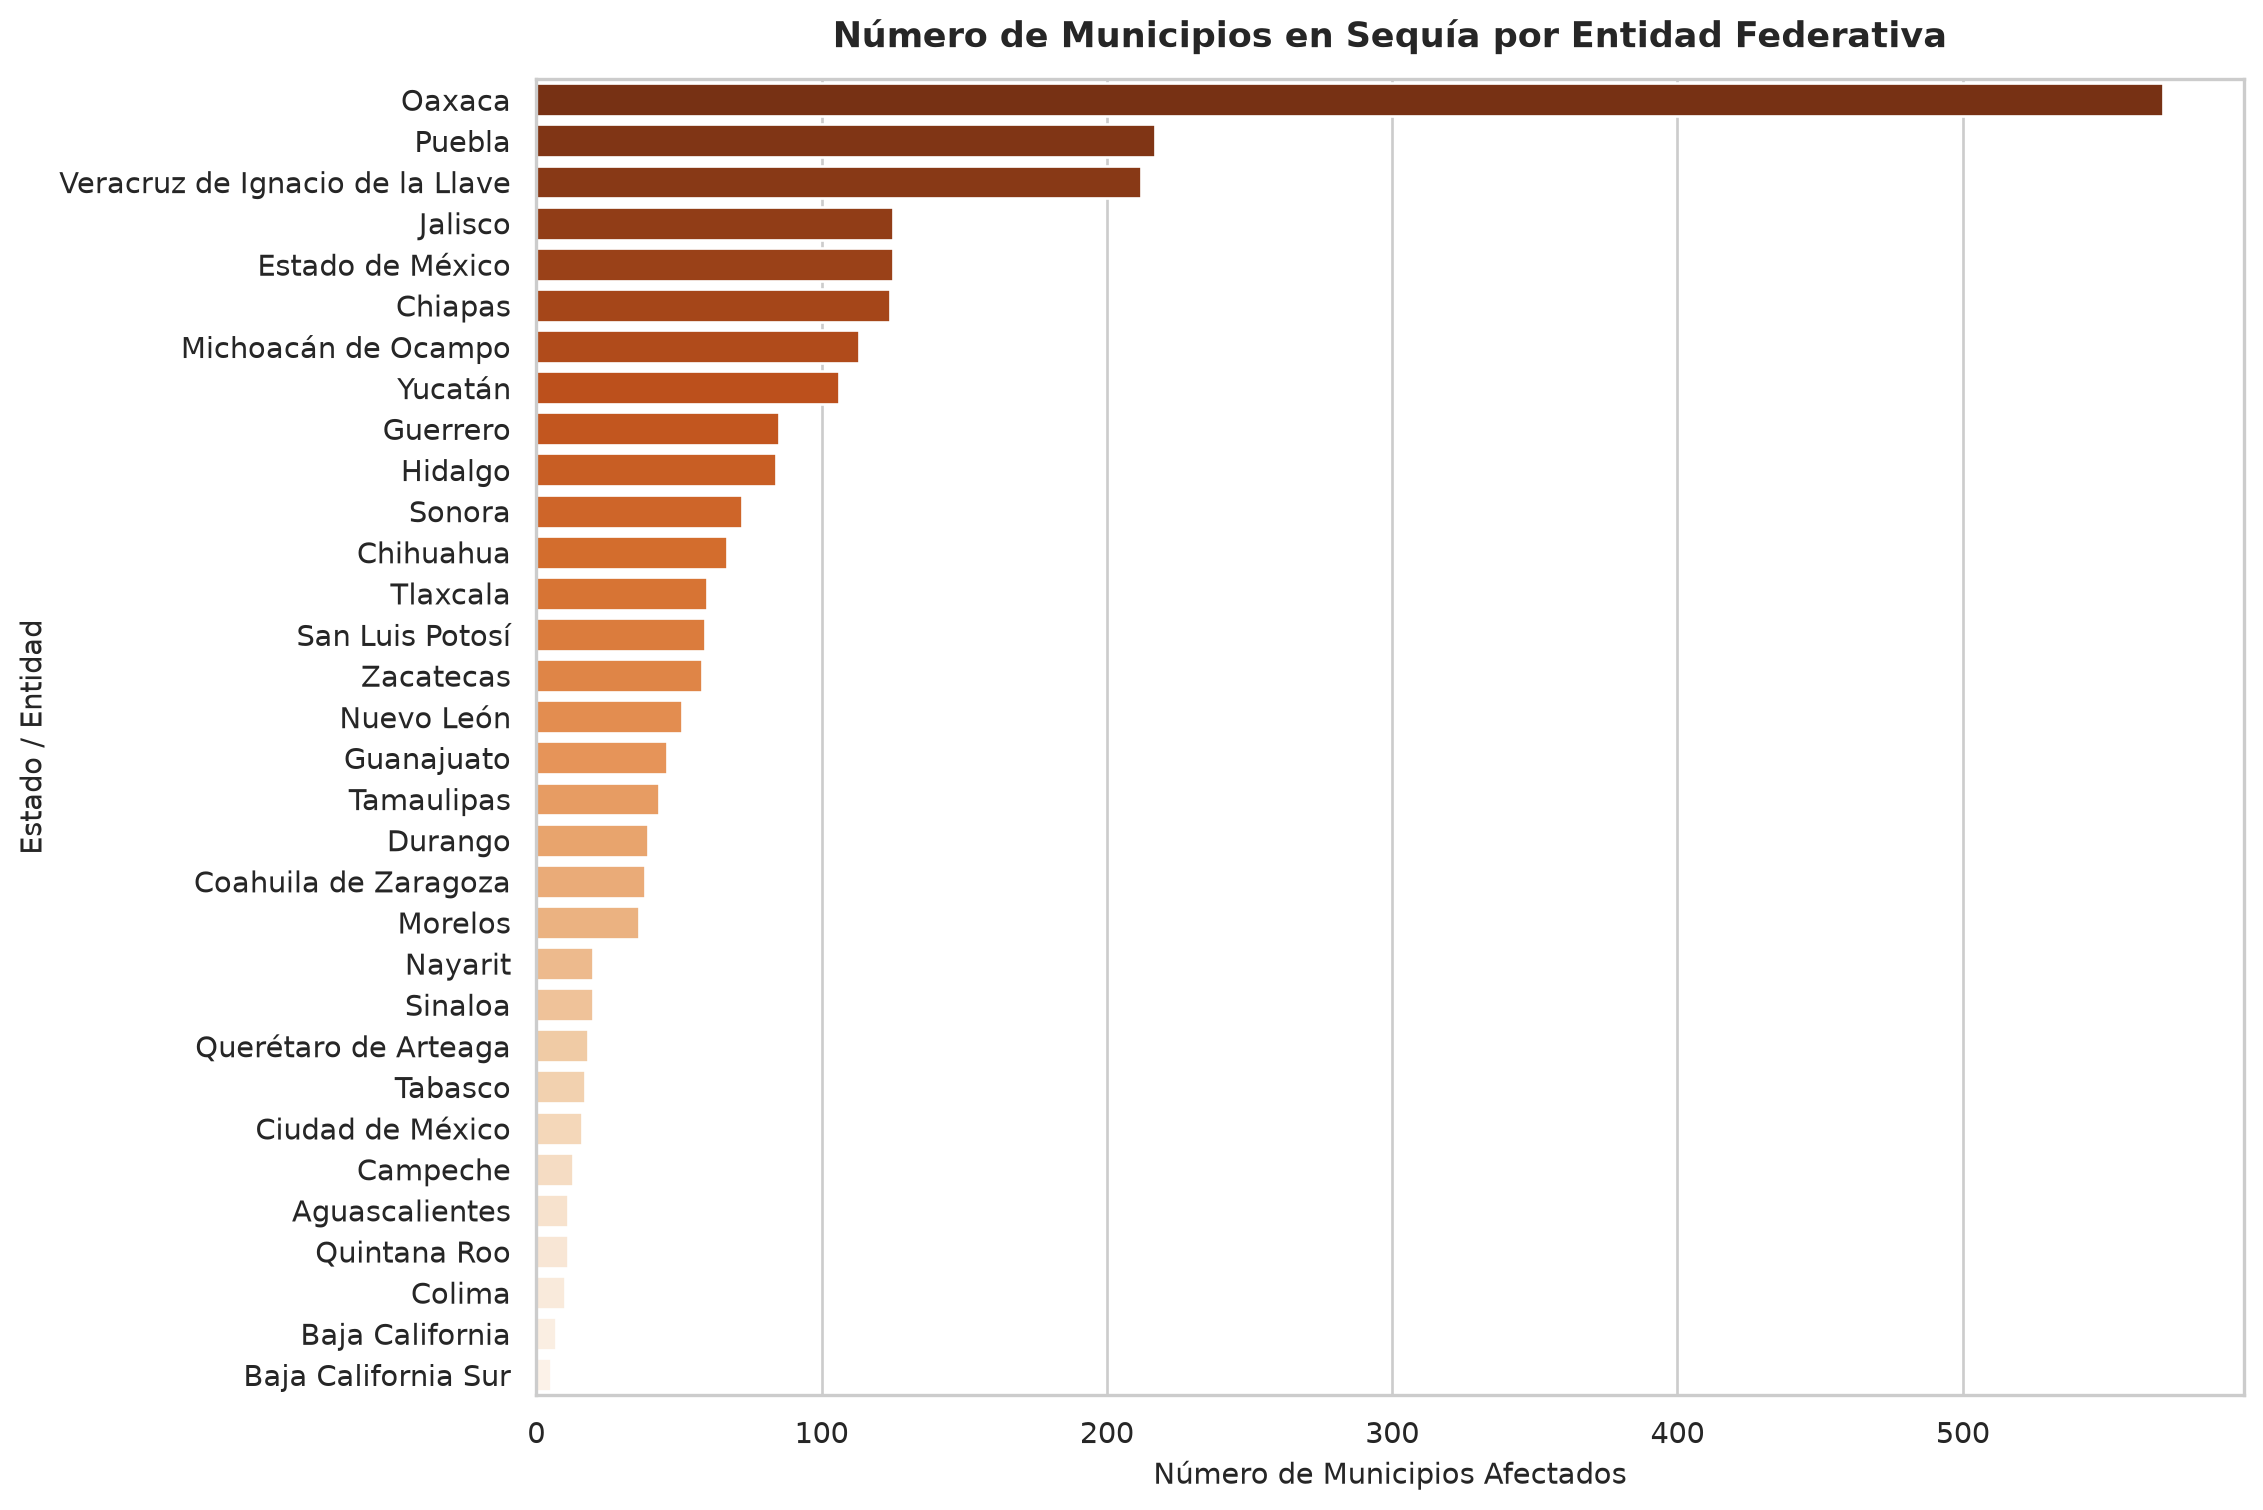

In [6]:
# GRAFICA 4: Comparativo por Estado en una fecha reciente (o año completo)
# Filtrar o agrupar municipios en sequía por Estado
df_estado_mun = df_analitico[df_analitico['en_sequia'] == True].groupby('ENTIDAD')['CVE_CONCATENADA'].nunique().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=df_estado_mun, x='CVE_CONCATENADA', y='ENTIDAD', palette='Oranges_r')

plt.title('Número de Municipios en Sequía por Entidad Federativa', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Número de Municipios Afectados', fontsize=11)
plt.ylabel('Estado / Entidad', fontsize=11)
plt.tight_layout()

plt.savefig('grafica_sequia_por_estado.png', dpi=300)
plt.show()

In [7]:
import geopandas as gpd

In [8]:
#| code-fold: true
#| code-summary: "Ver código de la gráfica interactiva"

import pandas as pd
import plotly.express as px

df = pd.read_parquet("../data/processed/sequia_analitico_2016.parquet")

evolucion = df.groupby(['fecha', 'intensidad_desc']).size().reset_index(name='conteo')

evolucion['porcentaje'] = evolucion.groupby('fecha')['conteo'].transform(lambda x: (x / x.sum()) * 100)
orden_categorias = [
    'Sin sequía', 
    'D0 Anormalmente seco', 
    'D1 Sequía moderada', 
    'D2 Sequía severa', 
    'D3 Sequía extrema', 
    'D4 Sequía excepcional'
]

colores_oficiales = {
    'Sin sequía': '#e0e0e0',          # Gris claro
    'D0 Anormalmente seco': '#ffff00', # Amarillo
    'D1 Sequía moderada': '#fcd37f',   # Naranja claro
    'D2 Sequía severa': '#ffaa00',     # Naranja oscuro
    'D3 Sequía extrema': '#e60000',    # Rojo
    'D4 Sequía excepcional': '#730000' # Rojo oscuro / Guinda
}

fig = px.area(
    evolucion, 
    x='fecha', 
    y='porcentaje', 
    color='intensidad_desc',
    category_orders={'intensidad_desc': orden_categorias},
    color_discrete_map=colores_oficiales
)

fig.update_layout(
    title='<b>Evolución Nacional de la Sequía en México (2016 - 2026)</b>',
    xaxis_title='',
    yaxis_title='% de Municipios del País',
    template='plotly_white',
    hovermode='x unified',
    legend_title_text='Nivel de Severidad',
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.25,
        xanchor="center",
        x=0.5
    ),
    margin=dict(l=20, r=20, t=50, b=20)
)

fig.update_yaxes(range=[0, 100])

fig.show()